# 📘 Домашнє завдання №19. Задача кластеризації: DBSCAN, ієрархічна кластеризація

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW19


## 1. Застосувати K-Means

### Необхідно:
- навчити модель K-Means
- використати `n_clusters=3`
- візуалізувати результати кластеризації
- показати центроїди кластерів

---

## 2. Застосувати DBSCAN

### Необхідно:
- підібрати параметри:
  - `eps`
  - `min_samples`
- візуалізувати результати
- визначити:
  - кількість кластерів
  - кількість шумових точок

---

## 3. Застосувати Agglomerative Clustering

### Необхідно:
- використати:
```python
AgglomerativeClustering
```

- спробувати різні `linkage methods`:
  - `ward`
  - `complete`
  - `average`

- порівняти результати

---

## 4. Побудувати дендрограму

### Необхідно:
- побудувати дендрограму
- пояснити:
  - як визначити кількість кластерів
  - що означають великі вертикальні відстані

---

## 5. Обчислити метрики якості

Для кожного алгоритму обчислити:

### Внутрішні метрики:
- Silhouette Score
- Calinski-Harabasz Index
- Davies-Bouldin Index

### Зовнішні метрики:
(оскільки справжні мітки відомі)
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "matplotlib",
#     "scipy",
#     "statsmodels",
#     "joblib",
#     "seaborn",
#     "kneed",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
# hm_version = 19
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

## ✳️ Підготовка датасетів

In [91]:
# Data synthesis

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import make_blobs

# Input data
rng_seed = 42
f1_col_name = "Feature 1"
f2_col_name = "Feature 2"
y_col_name = "Cluster ID"

# Solution
pd.options.display.float_format = "{:g}".format
np.random.seed(rng_seed)

# Генерація основних кластерів
X_data, Y_data = make_blobs(
    n_samples=470,
    centers=3,
    cluster_std=1.0,
    random_state=rng_seed
)

# Генерація шуму
noise = np.random.uniform(
    low=-15,
    high=15,
    size=(30, 2)
)

# Об'єднання кластерів та шуму
X_data = np.vstack([X_data, noise])

# Мітки для шуму
noise_labels = [-1] * len(noise)  # type: ignore

Y_data = np.concatenate([Y_data, noise_labels])

cluster_dataset = pd.DataFrame({
    f1_col_name: X_data[:, 0],
    f2_col_name: X_data[:, 1],
    y_col_name: Y_data,
})

# Print results
display(cluster_dataset.head(10).style.set_caption("Синтетичний dataset з трьома кластерами та шумом"))
display(cluster_dataset.groupby(y_col_name)
        .size()
        .to_frame(name='count')
        .style.set_caption("Кластери та кількість точок"))


,Feature 1,Feature 2,Cluster ID
0,4.152273,1.540611,1
1,-6.797343,-5.814629,2
2,5.285255,3.341801,1
3,4.737555,1.200160,1
4,-6.571825,-8.590278,2
5,-5.684581,-8.403296,2
6,2.947414,3.502720,1
7,-1.203719,9.035290,0
8,-3.499734,8.447988,0
9,-3.522029,9.328533,0


,count
Cluster ID,
-1,30
0,157
1,157
2,156


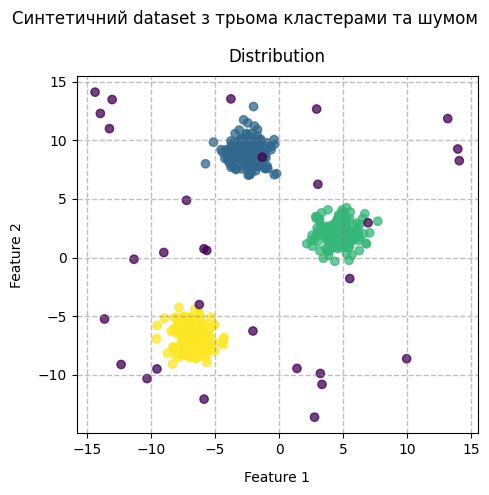

In [4]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = cluster_dataset

# Solution
_, axes = plt.subplots(figsize=(5, 5))

ax = axes
ax.scatter(x=data_set[f1_col_name], y=data_set[f2_col_name], c=data_set[y_col_name], alpha=0.75)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_xlabel(data_set.columns[0], labelpad=10, loc='center', color='black')
ax.set_ylabel(data_set.columns[1], labelpad=10, loc='center', color='black')

plt.suptitle("Синтетичний dataset з трьома кластерами та шумом")

plt.tight_layout()
plt.show()

In [5]:
# Data description

import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.display import display
from IPython.core.display import Markdown

# Input data
ds_name = "Synthetic dataset"
n_first_rows = 5

# Solution
data_set = cluster_dataset

n_columns = data_set.columns.size
n_rows = data_set.index.size

types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number)
col_cat_type = data_set.select_dtypes(exclude=np.number)

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.columns.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Аналіз даних"))
display(data_set.head(n_first_rows).style.set_caption(f"Перші {n_first_rows} рядків датасету"))

rp.print_pd_report("Параметри таблиці")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))

display(data_set.describe().T.style.format("{:g}").set_caption("Статистика числових змінних"))


### Аналіз даних

,Feature 1,Feature 2,Cluster ID
0,4.152273,1.540611,1
1,-6.797343,-5.814629,2
2,5.285255,3.341801,1
3,4.737555,1.200160,1
4,-6.571825,-8.590278,2


Attribute,Result
Кількість рядків,500
Кількість стовпців,3
Кількість числових ознак,3
Кількість категоріальних ознак,0
Пропущені значення,немає


,Types
Feature 1,float64
Feature 2,float64
Cluster ID,int64


,count,mean,std,min,25%,50%,75%,max
Feature 1,500,-1.62759,5.16901,-14.3825,-6.29065,-2.47991,3.88144,14.0875
Feature 2,500,1.37472,6.7297,-13.6065,-6.14441,1.8218,8.39721,14.0973
Cluster ID,500,0.878,0.923483,-1,0,1,2,2


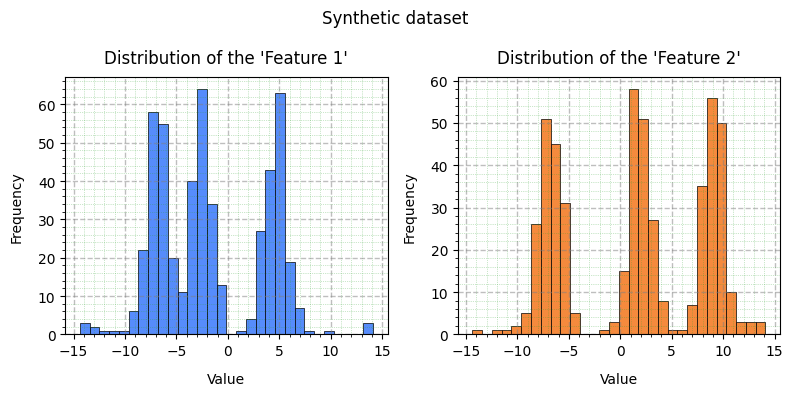

In [6]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
n_bins = 30
n_columns = 2
data_set = cluster_dataset.drop(columns=[y_col_name])

# Solution
axes = data_set.plot.hist(subplots=True, layout=(-1, n_columns), figsize=(8, 4),
                          bins=n_bins, edgecolor="black", linewidth=0.5, sharex=False, sharey=False)

for i, ax in enumerate(axes.flatten()):
    legend_text = ax.get_legend().get_texts()[0].get_text()

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(f"Distribution of the '{legend_text}'", pad=10, loc='center', color='black')
    ax.set_xlabel("Value", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Frequency", labelpad=10, loc='center', color='black')
    ax.get_legend().set_visible(False)

plt.suptitle(ds_name)

plt.tight_layout()
plt.show()

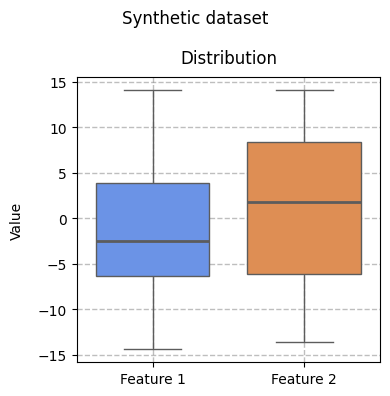

In [7]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data
data_set = cluster_dataset.drop(columns=[y_col_name])

# Solution
_, ax = plt.subplots(figsize=(4, 4))

sns.boxplot(data_set, ax=ax, width=0.75, medianprops={'linewidth': 2.0})

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_ylabel("Value", labelpad=10, loc='center', color='black')

plt.suptitle(ds_name)

plt.tight_layout()
plt.show()

In [8]:
# Additionally

# Input data
n_bins_1 = 40
n_bins_2 = 40
data_set = cluster_dataset

# Solution
data_f1 = data_set.iloc[:, 0]
data_f2 = data_set.iloc[:, 1]

bins_f1 = np.linspace(data_f1.min(), data_f1.max(), n_bins_1 + 1).round(2)
bins_f2 = np.linspace(data_f2.min(), data_f2.max(), n_bins_1 + 1).round(2)

f1_cut = pd.cut(data_f1, bins=bins_f1, include_lowest=True)
f2_cut = pd.cut(data_f2, bins=bins_f2, include_lowest=True)

f_matrix = pd.crosstab(f2_cut, f1_cut, dropna=False).sort_index(ascending=False)

# Print results
# display(f_matrix.style.set_caption("Растеризація точок"))

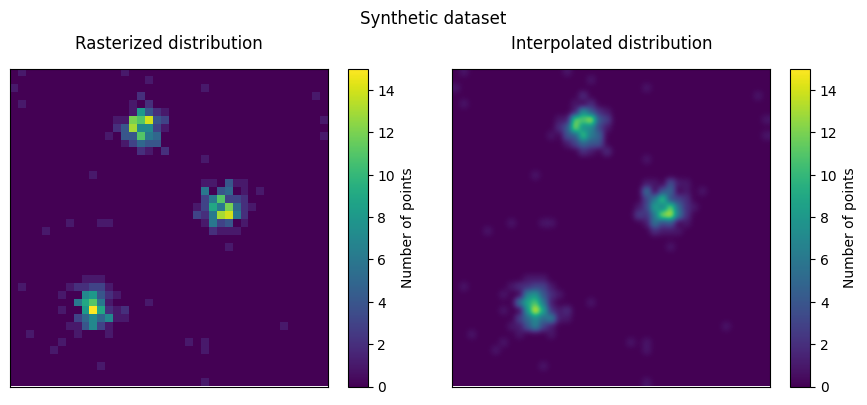

In [9]:
# Graphic results

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Input data

# Solution
_, axes = plt.subplots(1, 2, figsize=(9, 4))

ax = axes[0]
ax.imshow(f_matrix)
# ax.contour(f_matrix, levels=2, colors='white', linewidths=1.5)

ax.set_yticks([])
ax.set_xticks([])
# ax.set_yticks(range(len(f_matrix)), labels=f_matrix.index)
# ax.set_xticks(range(len(f_matrix)), labels=f_matrix.columns)
# plt.setp(ax.get_xticklabels(), rotation=90)

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(f_matrix.values.min(), f_matrix.values.max())
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Number of points')
ax.set_title("Rasterized distribution", pad=15, loc='center', color='black')

ax = axes[1]
ax.imshow(f_matrix, interpolation='gaussian')
# ax.contour(f_matrix, levels=2, colors='white', linewidths=1.5)

ax.set_yticks([])
ax.set_xticks([])
# ax.set_yticks(range(len(f_matrix)), labels=f_matrix.index)
# ax.set_xticks(range(len(f_matrix)), labels=f_matrix.columns)
# plt.setp(ax.get_xticklabels(), rotation=90)

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(f_matrix.values.min(), f_matrix.values.max())
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Number of points')
ax.set_title("Interpolated distribution", pad=15, loc='center', color='black')

plt.suptitle(ds_name)

plt.tight_layout()
plt.show()

In [10]:
# Scaling

from sklearn.preprocessing import StandardScaler

# Input data
cluster_dataset_sc = cluster_dataset.copy()
data_set = cluster_dataset_sc
data_set.drop(columns=[y_col_name], inplace=True)

# Solution
scaler = StandardScaler()

col_num_type = data_set.select_dtypes(include=np.number)

for col_name in col_num_type.columns:
    col_data = data_set[col_name].values.reshape(-1, 1)
    scaled_data = scaler.fit_transform(col_data)
    data_set[col_name] = scaled_data

data_set[y_col_name] = cluster_dataset[y_col_name]

# Print results
display(data_set.describe().T.style.format("{:g}").set_caption("Статистика масштабованих числових змінних"))


,count,mean,std,min,25%,50%,75%,max
Feature 1,500,3.55271e-18,1.001,-2.47004,-0.903023,-0.165056,1.06685,3.0433
Feature 2,500,3.01981e-17,1.001,-2.22836,-1.11843,0.0665001,1.04455,1.8924
Cluster ID,500,0.878,0.923483,-1,0,1,2,2


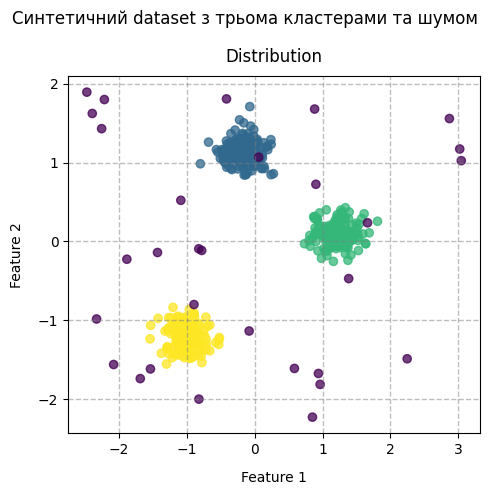

In [11]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = cluster_dataset_sc

# Solution
_, axes = plt.subplots(figsize=(5, 5))

ax = axes
ax.scatter(x=data_set[f1_col_name], y=data_set[f2_col_name], c=data_set[y_col_name], alpha=0.75)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_xlabel(data_set.columns[0], labelpad=10, loc='center', color='black')
ax.set_ylabel(data_set.columns[1], labelpad=10, loc='center', color='black')

plt.suptitle("Синтетичний dataset з трьома кластерами та шумом")

plt.tight_layout()
plt.show()

## ✅ Рішення 1

Необхідно:
- навчити модель K-Means
- використати `n_clusters=3`
- візуалізувати результати кластеризації
- показати центроїди кластерів


In [92]:
 # K-Means

from sklearn.cluster import KMeans

# Input data
n_clusters_kmean = 3
rng_seed = 42
n_max_clusters = 10
k_means_col_name = "k_means"
data_set = cluster_dataset_sc[[f1_col_name, f2_col_name]]

# Solution
kmeans = KMeans(
    n_clusters=n_clusters_kmean,
    init="k-means++",
    random_state=rng_seed,
    n_init=10,
)
labels_kmeans = kmeans.fit_predict(data_set.values)
centroids_kmeans = kmeans.cluster_centers_

cluster_dataset_sc[k_means_col_name] = labels_kmeans

# Print results
display(cluster_dataset_sc)
display(cluster_dataset_sc.groupby([k_means_col_name])
        .size()
        .to_frame(name='count')
        .style.set_caption("Кластери та кількість точок"))


,Feature 1,Feature 2,Cluster ID,k_means,dbscan
0,1.1193,0.0246747,1,1,0
1,-1.00115,-1.06937,2,0,1
2,1.3387,0.292591,1,1,0
3,1.23264,-0.0259654,1,1,0
4,-0.957474,-1.48223,2,0,1
...,...,...,...,...,...
495,3.0433,1.02325,-1,1,-1
496,2.86852,1.55736,-1,1,-1
497,0.883952,1.67805,-1,2,-1
498,-2.07552,-1.5611,-1,0,-1


,count
k_means,
0,169
1,166
2,165


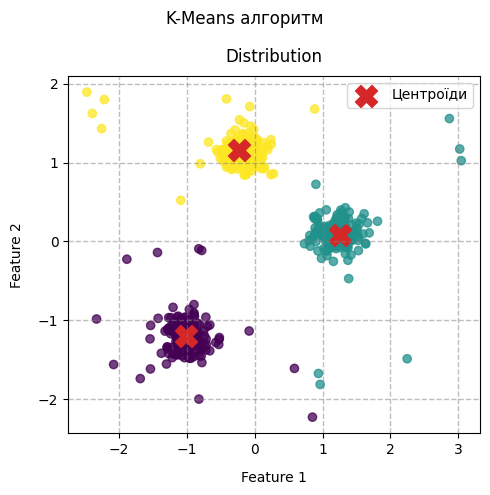

In [13]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = cluster_dataset_sc

# Solution
_, axes = plt.subplots(figsize=(5, 5))

ax = axes
ax.scatter(x=data_set[f1_col_name], y=data_set[f2_col_name], c=data_set[k_means_col_name], alpha=0.75)
ax.scatter(x=centroids_kmeans[:, 0], y=centroids_kmeans[:, 1], marker='X', s=250, color="tab:red", label='Центроїди')

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_xlabel(data_set.columns[0], labelpad=10, loc='center', color='black')
ax.set_ylabel(data_set.columns[1], labelpad=10, loc='center', color='black')
ax.legend()

plt.suptitle("K-Means алгоритм")

plt.tight_layout()
plt.show()

## ✅ Рішення 2

Необхідно:
- підібрати параметри:
  - `eps`
  - `min_samples`
- візуалізувати результати
- визначити:
  - кількість кластерів
  - кількість шумових точок


In [93]:
# DBSCAN

import apps.reporter as rpt
from sklearn.cluster import DBSCAN

# Input data
eps_opt = 0.225
min_samples_opt = 3
dbscan_col_name = "dbscan"
data_set = cluster_dataset_sc[[f1_col_name, f2_col_name]]

# Solution
dbscan = DBSCAN(
    eps=eps_opt,
    min_samples=min_samples_opt,
)

labels_dbscan = dbscan.fit_predict(data_set.values)

cluster_dataset_sc[dbscan_col_name] = labels_dbscan

n_clusters_dbscan = cluster_dataset_sc[cluster_dataset_sc[dbscan_col_name] > -1][dbscan_col_name].nunique()
n_noise_points_dbscan = cluster_dataset_sc[cluster_dataset_sc[dbscan_col_name] <= -1][dbscan_col_name].count()

rp = rpt.Reporter()
rp.add_item("Максимальний радіус, Epsilon", str(eps_opt))
rp.add_item("Мінімальна кількість точок у радіусі, MinPts", str(min_samples_opt))
rp.add_item("Кількість кластерів", str(n_clusters_dbscan))
rp.add_item("Кількість шумових точок", str(n_noise_points_dbscan))

# Print results
rp.print_pd_report("DBSCAN аналіз")

display(cluster_dataset_sc)
display(cluster_dataset_sc.groupby(dbscan_col_name)
        .size()
        .to_frame(name='count')
        .style.set_caption("Кластери та кількість точок"))

Attribute,Result
"Максимальний радіус, Epsilon",0.225
"Мінімальна кількість точок у радіусі, MinPts",3
Кількість кластерів,3
Кількість шумових точок,28


,Feature 1,Feature 2,Cluster ID,k_means,dbscan
0,1.1193,0.0246747,1,1,0
1,-1.00115,-1.06937,2,0,1
2,1.3387,0.292591,1,1,0
3,1.23264,-0.0259654,1,1,0
4,-0.957474,-1.48223,2,0,1
...,...,...,...,...,...
495,3.0433,1.02325,-1,1,-1
496,2.86852,1.55736,-1,1,-1
497,0.883952,1.67805,-1,2,-1
498,-2.07552,-1.5611,-1,0,-1


,count
dbscan,
-1,28
0,158
1,157
2,157


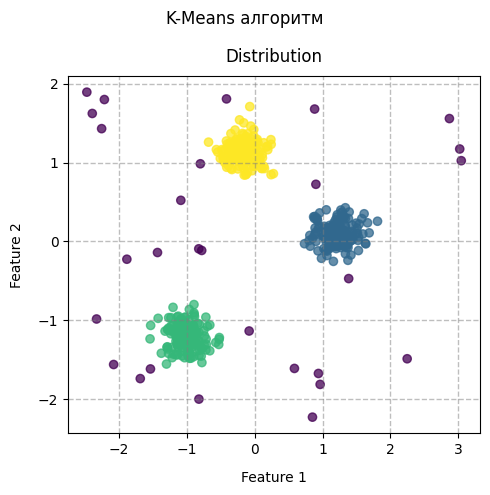

In [78]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = cluster_dataset_sc

# Solution
_, axes = plt.subplots(figsize=(5, 5))

ax = axes
ax.scatter(x=data_set[f1_col_name], y=data_set[f2_col_name], c=data_set[dbscan_col_name], alpha=0.75)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_xlabel(data_set.columns[0], labelpad=10, loc='center', color='black')
ax.set_ylabel(data_set.columns[1], labelpad=10, loc='center', color='black')

plt.suptitle("K-Means алгоритм")

plt.tight_layout()
plt.show()